# Calibration & Reliability Analysis

This notebook evaluates the probability calibration and reliability of the three Random Forest models selected during validation:

- Demographics + Questionnaire Random Forest
- Wearable + Questionnaire Random Forest
- Full Multimodal Random Forest

The analysis compares uncalibrated probabilities with sigmoid and isotonic calibration using multiclass Brier Scores, validation accuracy, and class-specific calibration curves.

## Importing libraries and setting paths 

In [29]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import accuracy_score

PROJECT_ROOT = Path.cwd().parent

OUTPUT_METRICS = PROJECT_ROOT / "outputs" / "metrics"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"

OUTPUT_METRICS.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

# Calibration of All Selected Candidate Models

The three Random Forest models selected during validation are evaluated for probability calibration:

1. Demographics + Questionnaire Random Forest
2. Wearable + Questionnaire Random Forest
3. Full Multimodal Random Forest

For each model, uncalibrated probabilities are compared with sigmoid and isotonic calibration using multiclass Brier Scores and class-specific calibration curves.

In [18]:
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import accuracy_score

def multiclass_brier_score(y_true, probabilities, classes):
    y_onehot = np.column_stack([
        (y_true.to_numpy() == cls).astype(int)
        for cls in classes
    ])

    return np.mean(
        np.sum(
            (probabilities - y_onehot) ** 2,
            axis=1
        )
    )


def calibrate_selected_model(
    model_name,
    model_filename,
    train_filename,
    validation_filename,
    short_name
):
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    model_path = PROJECT_ROOT / "models" / model_filename
    train_path = PROJECT_ROOT / "data" / "processed" / train_filename
    validation_path = PROJECT_ROOT / "data" / "processed" / validation_filename

    print("Model exists:", model_path.exists())
    print("Train exists:", train_path.exists())
    print("Validation exists:", validation_path.exists())

    # Load model and datasets
    selected_model = joblib.load(model_path)

    train_data = pd.read_csv(train_path)
    validation_data = pd.read_csv(validation_path)

    TARGET = "label"

    y_train_local = train_data[TARGET]
    y_val_local = validation_data[TARGET]

    # Use exactly the features expected by the saved model
    if hasattr(selected_model, "feature_names_in_"):
        feature_columns_local = list(
            selected_model.feature_names_in_
        )
    else:
        exclude_columns = [
            "patient_id",
            "condition_original",
            "condition_group",
            "label"
        ]

        feature_columns_local = [
            col for col in train_data.columns
            if col not in exclude_columns
        ]

    X_train_local = train_data[
        feature_columns_local
    ].copy()

    X_val_local = validation_data[
        feature_columns_local
    ].copy()

    print("Number of features:", len(feature_columns_local))
    print("Train shape:", X_train_local.shape)
    print("Validation shape:", X_val_local.shape)
    print(
        "total_symptom_count included:",
        "total_symptom_count" in feature_columns_local
    )

    # ---------------------------------------------------------
    # Uncalibrated
    # ---------------------------------------------------------
    uncal_prob = selected_model.predict_proba(
        X_val_local
    )

    classes_local = np.asarray(
        selected_model.classes_
    )

    uncal_brier = multiclass_brier_score(
        y_val_local,
        uncal_prob,
        classes_local
    )

    uncal_pred = classes_local[
        np.argmax(uncal_prob, axis=1)
    ]

    uncal_accuracy = accuracy_score(
        y_val_local,
        uncal_pred
    )

    # ---------------------------------------------------------
    # Sigmoid calibration
    # ---------------------------------------------------------
    sigmoid_calibrator = CalibratedClassifierCV(
        estimator=clone(selected_model),
        method="sigmoid",
        cv=5
    )

    sigmoid_calibrator.fit(
        X_train_local,
        y_train_local
    )

    sigmoid_prob_local = (
        sigmoid_calibrator.predict_proba(
            X_val_local
        )
    )

    sigmoid_brier_local = multiclass_brier_score(
        y_val_local,
        sigmoid_prob_local,
        classes_local
    )

    sigmoid_pred = classes_local[
        np.argmax(sigmoid_prob_local, axis=1)
    ]

    sigmoid_accuracy = accuracy_score(
        y_val_local,
        sigmoid_pred
    )

    # ---------------------------------------------------------
    # Isotonic calibration
    # ---------------------------------------------------------
    isotonic_calibrator = CalibratedClassifierCV(
        estimator=clone(selected_model),
        method="isotonic",
        cv=5
    )

    isotonic_calibrator.fit(
        X_train_local,
        y_train_local
    )

    isotonic_prob_local = (
        isotonic_calibrator.predict_proba(
            X_val_local
        )
    )

    isotonic_brier_local = multiclass_brier_score(
        y_val_local,
        isotonic_prob_local,
        classes_local
    )

    isotonic_pred = classes_local[
        np.argmax(isotonic_prob_local, axis=1)
    ]

    isotonic_accuracy = accuracy_score(
        y_val_local,
        isotonic_pred
    )

    # ---------------------------------------------------------
    # Display scores
    # ---------------------------------------------------------
    print("\nBrier Scores")
    print("Uncalibrated:", round(uncal_brier, 6))
    print("Sigmoid:", round(sigmoid_brier_local, 6))
    print("Isotonic:", round(isotonic_brier_local, 6))

    # ---------------------------------------------------------
    # Calibration curves
    # ---------------------------------------------------------
    probability_sets = {
        "Uncalibrated": uncal_prob,
        "Sigmoid": sigmoid_prob_local,
        "Isotonic": isotonic_prob_local
    }

    for class_index, cls in enumerate(classes_local):

        plt.figure(figsize=(8, 6))

        y_binary = (
            y_val_local.to_numpy() == cls
        ).astype(int)

        for method_name, probabilities in probability_sets.items():

            prob_true, prob_pred = calibration_curve(
                y_binary,
                probabilities[:, class_index],
                n_bins=8,
                strategy="quantile"
            )

            plt.plot(
                prob_pred,
                prob_true,
                marker="o",
                label=method_name
            )

        plt.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            label="Perfect calibration"
        )

        plt.xlabel("Mean Predicted Probability")
        plt.ylabel("Observed Proportion")

        plt.title(
            f"{model_name}\nCalibration Curve - Class {cls}"
        )

        plt.legend()
        plt.tight_layout()

        figure_path = (
            OUTPUT_FIGURES
            / f"{short_name}_calibration_class_{cls}.png"
        )

        plt.savefig(
            figure_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

    # ---------------------------------------------------------
    # Return results
    # ---------------------------------------------------------
    results = pd.DataFrame({
        "Model": [model_name] * 3,
        "Calibration_Method": [
            "Uncalibrated",
            "Sigmoid",
            "Isotonic"
        ],
        "Multiclass_Brier_Score": [
            uncal_brier,
            sigmoid_brier_local,
            isotonic_brier_local
        ],
        "Validation_Accuracy": [
            uncal_accuracy,
            sigmoid_accuracy,
            isotonic_accuracy
        ]
    })

    results["Improvement_vs_Uncalibrated"] = [
        0,
        uncal_brier - sigmoid_brier_local,
        uncal_brier - isotonic_brier_local
    ]

    return results

## Calibration for all three selected models 

Demographics + Questionnaire Random Forest
Model exists: True
Train exists: True
Validation exists: True
Number of features: 51
Train shape: (328, 51)
Validation shape: (70, 51)
total_symptom_count included: False

Brier Scores
Uncalibrated: 0.45348
Sigmoid: 0.422792
Isotonic: 0.422918


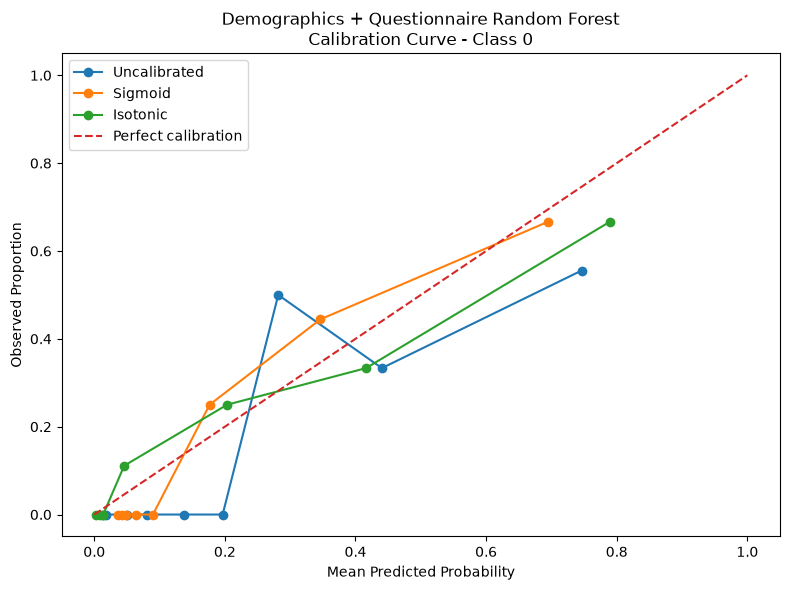

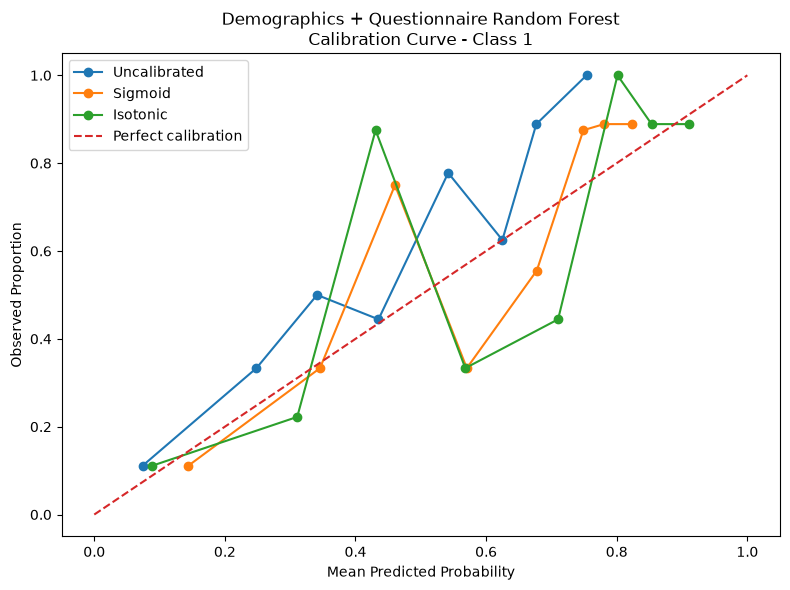

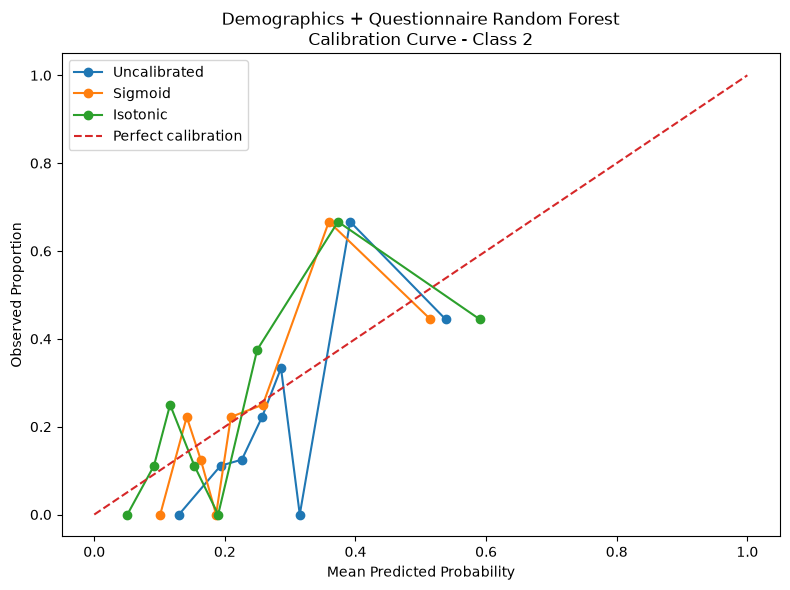

Wearable + Questionnaire Random Forest
Model exists: True
Train exists: True
Validation exists: True
Number of features: 2397
Train shape: (328, 2397)
Validation shape: (70, 2397)
total_symptom_count included: False

Brier Scores
Uncalibrated: 0.385592
Sigmoid: 0.312091
Isotonic: 0.304391


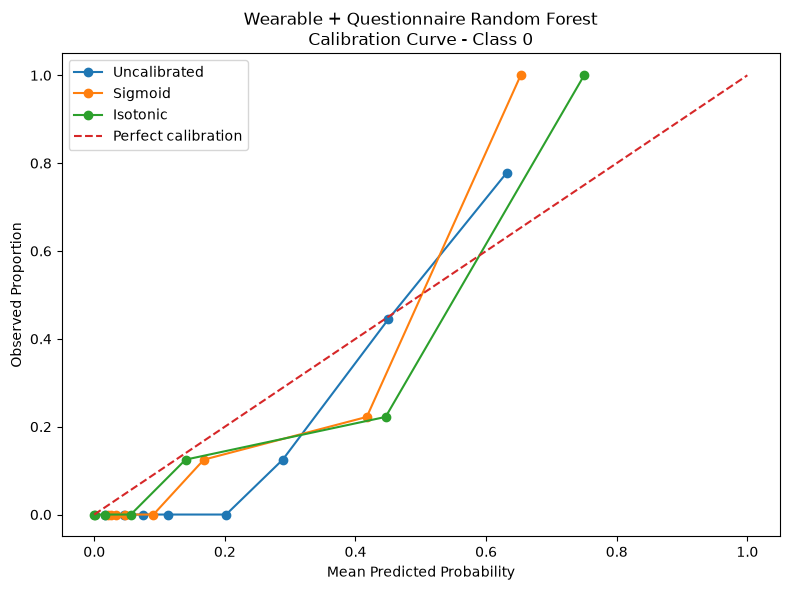

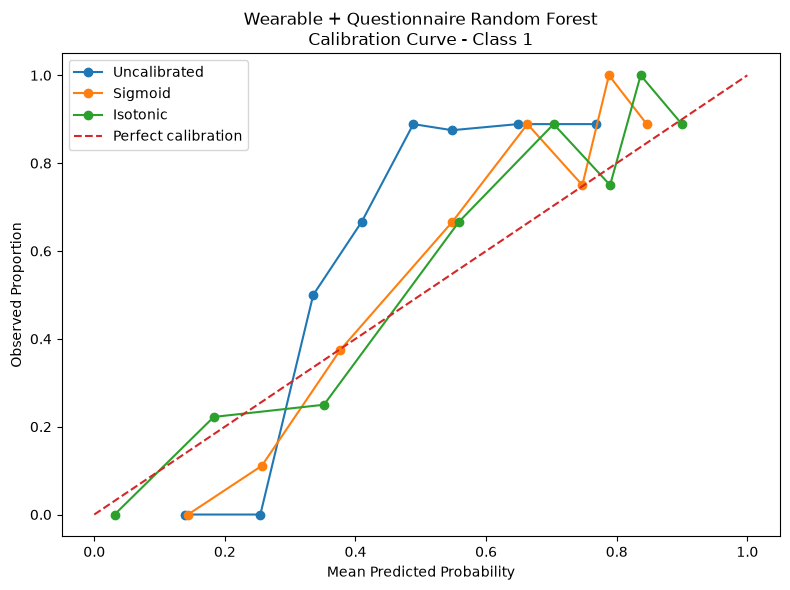

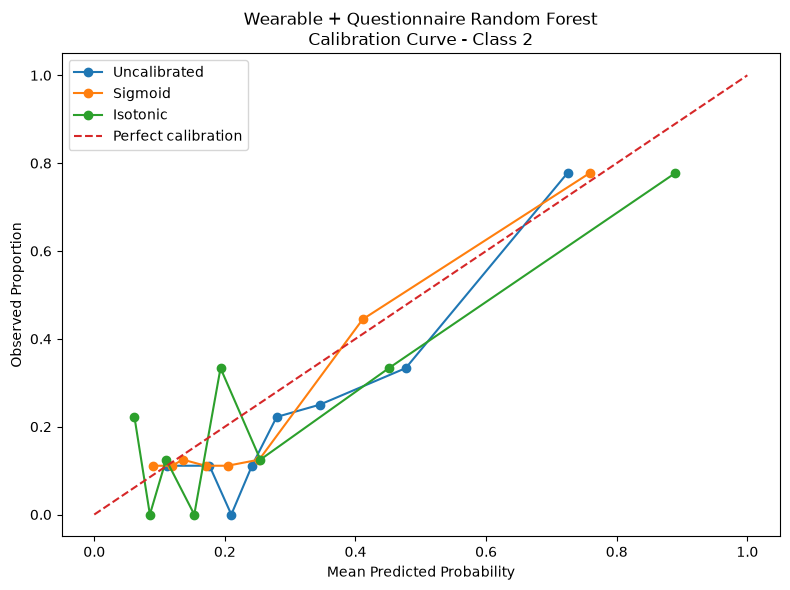

Full Multimodal Random Forest
Model exists: True
Train exists: True
Validation exists: True
Number of features: 2405
Train shape: (328, 2405)
Validation shape: (70, 2405)
total_symptom_count included: False

Brier Scores
Uncalibrated: 0.382643
Sigmoid: 0.319572
Isotonic: 0.306032


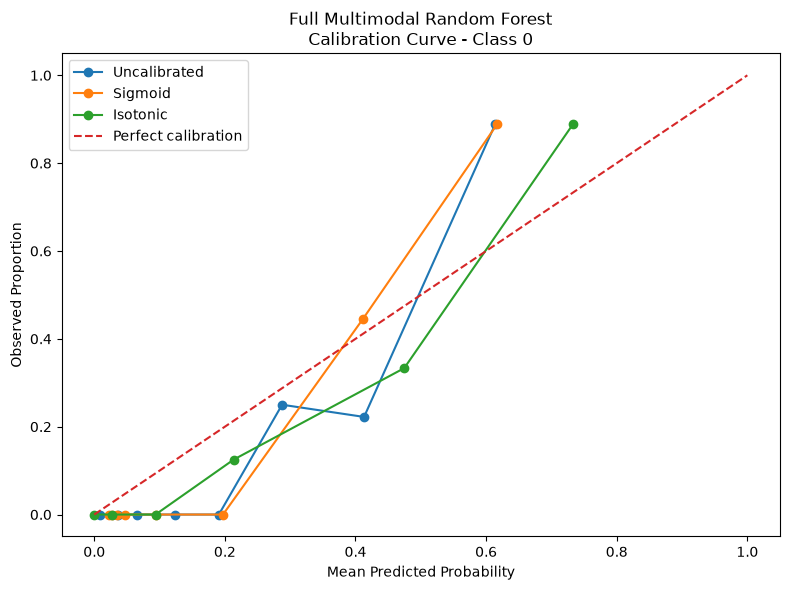

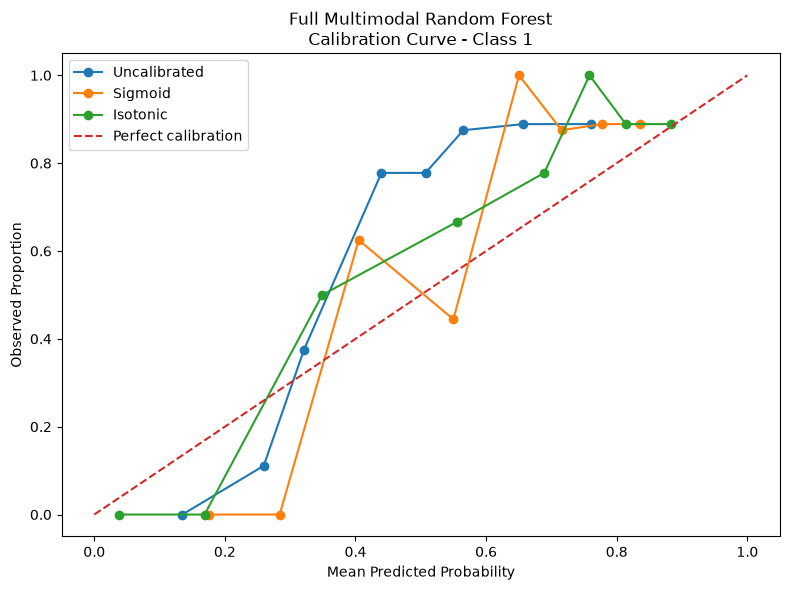

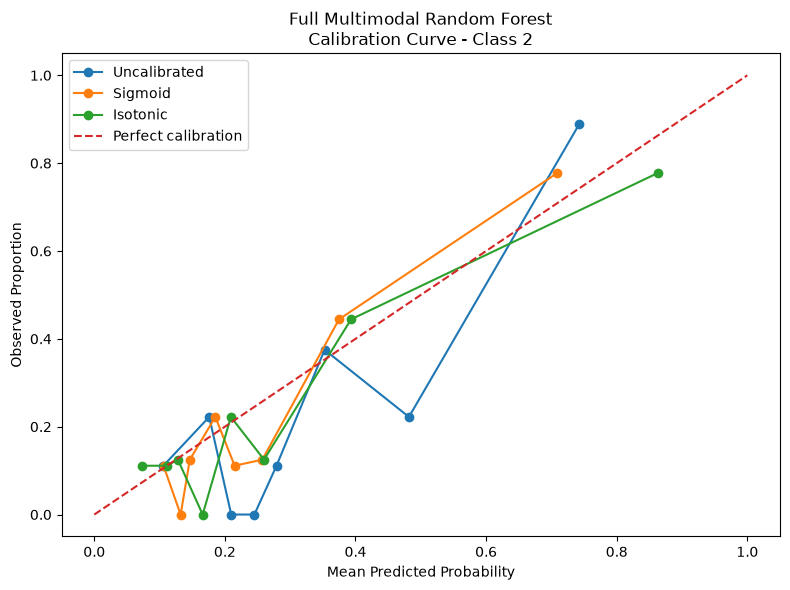

In [21]:
demographics_results = calibrate_selected_model(
    model_name="Demographics + Questionnaire Random Forest",
    model_filename="demographics_plus_questionnaire_random_forest.joblib",
    train_filename="train_demographics_questionnaire_task_aware.csv",
    validation_filename="validation_demographics_questionnaire_task_aware.csv",
    short_name="demographics_questionnaire_rf"
)

wearable_results = calibrate_selected_model(
    model_name="Wearable + Questionnaire Random Forest",
    model_filename="wearable_plus_questionnaire_random_forest.joblib",
    train_filename="train_wearable_questionnaire_task_aware.csv",
    validation_filename="validation_wearable_questionnaire_task_aware.csv",
    short_name="wearable_questionnaire_rf"
)

multimodal_results = calibrate_selected_model(
    model_name="Full Multimodal Random Forest",
    model_filename="full_multimodal_random_forest.joblib",
    train_filename="train_multimodal_full_task_aware.csv",
    validation_filename="validation_multimodal_full_task_aware.csv",
    short_name="multimodal_full_rf"
)

In [22]:
all_calibration_results = pd.concat(
    [
        demographics_results,
        wearable_results,
        multimodal_results
    ],
    ignore_index=True
)

all_calibration_results

,Model,Calibration_Method,Multiclass_Brier_Score,Validation_Accuracy,Improvement_vs_Uncalibrated
0,Demographics + Questionnaire Random Forest,Uncalibrated,0.453480,0.657143,0.000000
1,Demographics + Questionnaire Random Forest,Sigmoid,0.422792,0.657143,0.030688
2,Demographics + Questionnaire Random Forest,Isotonic,0.422918,0.642857,0.030561
3,Wearable + Questionnaire Random Forest,Uncalibrated,0.385592,0.800000,0.000000
4,Wearable + Questionnaire Random Forest,Sigmoid,0.312091,0.785714,0.073502
5,Wearable + Questionnaire Random Forest,Isotonic,0.304391,0.814286,0.081201
6,Full Multimodal Random Forest,Uncalibrated,0.382643,0.742857,0.000000
7,Full Multimodal Random Forest,Sigmoid,0.319572,0.785714,0.063071
8,Full Multimodal Random Forest,Isotonic,0.306032,0.800000,0.076611


## Brier Score Comparison

The table below compares the uncalibrated, sigmoid-calibrated, and isotonic-calibrated probability estimates for all three Random Forest models selected during validation. Lower Brier Scores indicate better probability calibration and reliability.

In [23]:
CALIBRATION_RESULTS_PATH = (
    OUTPUT_METRICS
    / "calibration_results.csv"
)

all_calibration_results.to_csv(
    CALIBRATION_RESULTS_PATH,
    index=False
)

print(
    "Saved:",
    CALIBRATION_RESULTS_PATH
)

Saved: /Users/user/Documents/GitHub/AI-Assisted-Screening-of-Parkinson-s-Disease/outputs/metrics/calibration_results.csv


## Best Calibration Method by Model

The lowest multiclass Brier Score for each candidate model is used to identify the calibration approach that provides the most reliable probability estimates.

In [24]:
best_calibration_by_model = (
    all_calibration_results
    .sort_values("Multiclass_Brier_Score")
    .groupby("Model", as_index=False)
    .first()
)

best_calibration_by_model

,Model,Calibration_Method,Multiclass_Brier_Score,Validation_Accuracy,Improvement_vs_Uncalibrated
0,Demographics + Questionnaire Random Forest,Sigmoid,0.422792,0.657143,0.030688
1,Full Multimodal Random Forest,Isotonic,0.306032,0.800000,0.076611
2,Wearable + Questionnaire Random Forest,Isotonic,0.304391,0.814286,0.081201


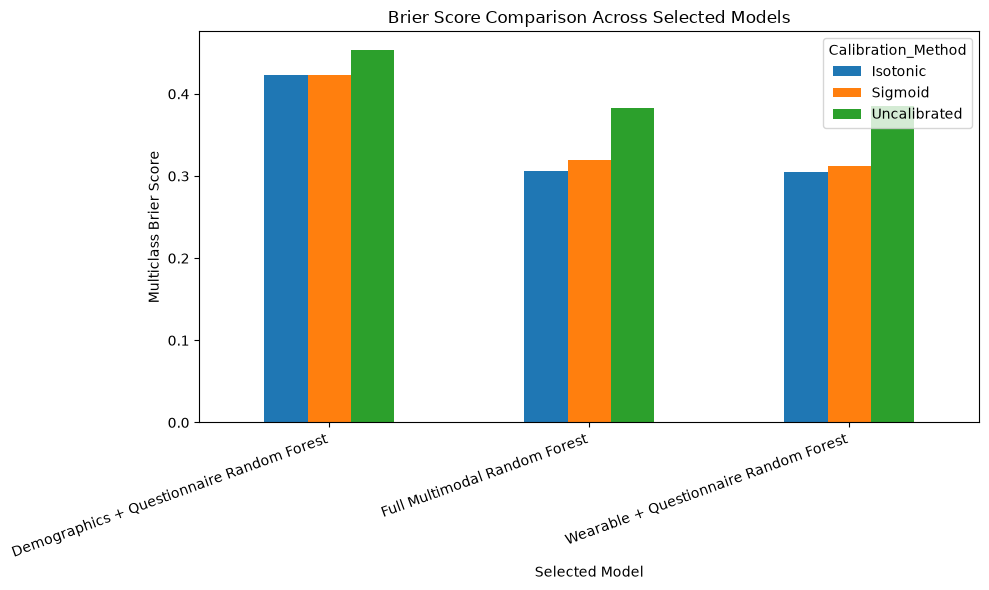

Saved: /Users/user/Documents/GitHub/AI-Assisted-Screening-of-Parkinson-s-Disease/outputs/figures/calibration_brier_score_comparison.png


In [25]:
# Creating the final Brier Score comparison figure
pivot_brier = (
    all_calibration_results
    .pivot(
        index="Model",
        columns="Calibration_Method",
        values="Multiclass_Brier_Score"
    )
)

ax = pivot_brier.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Multiclass Brier Score")
plt.xlabel("Selected Model")
plt.title(
    "Brier Score Comparison Across Selected Models"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

FINAL_BRIER_FIGURE = (
    OUTPUT_FIGURES
    / "calibration_brier_score_comparison.png"
)

plt.savefig(
    FINAL_BRIER_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", FINAL_BRIER_FIGURE)

In [26]:
prediction_comparison = (
    all_calibration_results[
        [
            "Model",
            "Calibration_Method",
            "Validation_Accuracy",
            "Multiclass_Brier_Score"
        ]
    ]
    .copy()
)

prediction_comparison

,Model,Calibration_Method,Validation_Accuracy,Multiclass_Brier_Score
0,Demographics + Questionnaire Random Forest,Uncalibrated,0.657143,0.453480
1,Demographics + Questionnaire Random Forest,Sigmoid,0.657143,0.422792
2,Demographics + Questionnaire Random Forest,Isotonic,0.642857,0.422918
3,Wearable + Questionnaire Random Forest,Uncalibrated,0.800000,0.385592
4,Wearable + Questionnaire Random Forest,Sigmoid,0.785714,0.312091
5,Wearable + Questionnaire Random Forest,Isotonic,0.814286,0.304391
6,Full Multimodal Random Forest,Uncalibrated,0.742857,0.382643
7,Full Multimodal Random Forest,Sigmoid,0.785714,0.319572
8,Full Multimodal Random Forest,Isotonic,0.800000,0.306032


## Calibrated vs. Uncalibrated Prediction Comparison

Calibration primarily aims to improve the reliability of predicted probabilities rather than classification accuracy. Therefore, both validation accuracy and multiclass Brier Score are reported. A reduction in Brier Score indicates improved probability reliability, even when classification accuracy remains similar.

## Calibration and Reliability Summary

Probability calibration was evaluated for the three Random Forest models selected during validation: Demographics + Questionnaire, Wearable + Questionnaire, and Full Multimodal.

Calibration improved the multiclass Brier Score for all three models. For the Demographics + Questionnaire model, sigmoid calibration performed best, reducing the Brier Score from 0.453480 to 0.422792. For the Wearable + Questionnaire model, isotonic calibration achieved the best result, reducing the Brier Score from 0.385592 to 0.304391. Isotonic calibration also performed best for the Full Multimodal model, reducing the Brier Score from 0.382643 to 0.306032.

Overall, the Wearable + Questionnaire Random Forest achieved the lowest calibrated Brier Score (0.304391), indicating the strongest probability reliability among the evaluated models. The class-specific calibration curves were also used to assess the agreement between predicted probabilities and observed outcomes.

In [28]:
print(
    "Calibration results CSV:",
    CALIBRATION_RESULTS_PATH.exists()
)

print(
    "Brier comparison figure:",
    FINAL_BRIER_FIGURE.exists()
)

expected_models = [
    "demographics_questionnaire_rf",
    "wearable_questionnaire_rf",
    "multimodal_full_rf"
]

for model_short_name in expected_models:
    for cls in [0, 1, 2]:
        file_path = (
            OUTPUT_FIGURES
            / f"{model_short_name}_calibration_class_{cls}.png"
        )

        print(
            file_path.name,
            ":",
            file_path.exists()
        )

Calibration results CSV: True
Brier comparison figure: True
demographics_questionnaire_rf_calibration_class_0.png : True
demographics_questionnaire_rf_calibration_class_1.png : True
demographics_questionnaire_rf_calibration_class_2.png : True
wearable_questionnaire_rf_calibration_class_0.png : True
wearable_questionnaire_rf_calibration_class_1.png : True
wearable_questionnaire_rf_calibration_class_2.png : True
multimodal_full_rf_calibration_class_0.png : True
multimodal_full_rf_calibration_class_1.png : True
multimodal_full_rf_calibration_class_2.png : True
